In [1]:
%load_ext autoreload
%autoreload 2

import torch
import numpy as np
import tqdm
import matplotlib.pyplot as plt

from utils.model_definitions.text_automodel_wrapper import TextLayerwiseAutoModelWrapper, TextModelSpecifications

from utils.metrics.metric_calling import (
    calculate_and_save_layerwise_metrics,
    EvaluationMetricSpecifications
)
import utils.metrics.metric_functions as mf
from utils.dataloaders.text_dataloader import (
    get_dataloader,
    get_augmentation_collated_dataloader
)
from utils.misc.optimal_batch_size import find_optimal_batch_size

## Make Model and Dataset

In [2]:
model_specs = TextModelSpecifications(
    model_family="Pythia",
    model_size="410m",
    revision="main"
)
model = TextLayerwiseAutoModelWrapper(model_specs, device_map="auto")
optimal_batch_size = find_optimal_batch_size(model, 2000, model.device)

print(f"Optimal batch size: {optimal_batch_size}")

/home/AD/ofsk222/miniconda3/envs/information_plane/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/home/AD/ofsk222/miniconda3/envs/information_plane/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Optimal batch size: 8


In [6]:
dataloader_wikitext = get_dataloader(
    model.tokenizer,
      "wikitext", 
      split="train", 
      num_samples=10000,
      batch_size=optimal_batch_size,
      num_workers=16,
      filter_text_columns=True
)

dataloader_amazon_counterfactual = get_dataloader(
    model.tokenizer,
    "mteb/amazon_counterfactual", 
    split="train", 
    num_samples=1000, 
    batch_size=optimal_batch_size,
    num_workers=4,
    filter_text_columns=True
)

Using the latest cached version of the dataset since wikitext couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'wikitext-103-v1' at /home/AD/ofsk222/.cache/huggingface/datasets/wikitext/wikitext-103-v1/0.0.0/b08601e04326c79dfdd32d625aee71d232d685c3 (last modified on Mon Jan 27 15:51:28 2025).


Filter:   0%|          | 0/10000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/8329 [00:00<?, ? examples/s]

Map:   0%|          | 0/4812 [00:00<?, ? examples/s]

Map:   0%|          | 0/4812 [00:00<?, ? examples/s]

Using the latest cached version of the module from /home/AD/ofsk222/.cache/huggingface/modules/datasets_modules/datasets/mteb--amazon_counterfactual/3b6ae425288b4ec49ffa16445fa595593e9c00e210da62c9cf576ad2acfe4a8b (last modified on Tue Sep 17 01:09:23 2024) since it couldn't be found locally at mteb/amazon_counterfactual, or remotely on the Hugging Face Hub.
Repo card metadata block was not found. Setting CardData to empty.


Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

# Prompt Entropy

In [4]:
evaluation_metric_specs = EvaluationMetricSpecifications(evaluation_metric="prompt-entropy", alpha=2) # alpha=2 for faster computation

wikitext_prompt_entropy = calculate_and_save_layerwise_metrics(
    model, 
    dataloader_wikitext, 
    model_specs, 
    evaluation_metric_specs, 
    dataloader_kwargs={"num_samples": 2000, "dataset_name": "wikitext"},
    should_save_results=False
)

mteb_amazon_counterfactual_prompt_entropy = calculate_and_save_layerwise_metrics(
    model, 
    dataloader_amazon_counterfactual, 
    model_specs, 
    evaluation_metric_specs, 
    dataloader_kwargs={"num_samples": 1000, "dataset_name": "mteb/amazon_counterfactual"},
    should_save_results=False
)

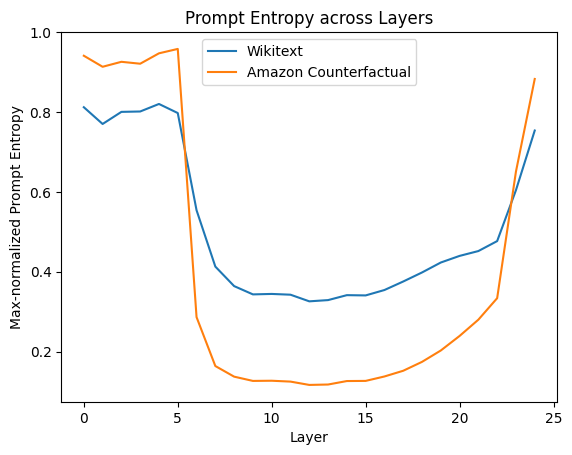

In [16]:
plt.plot(wikitext_prompt_entropy['maxEntropy'], label='Wikitext')
plt.plot(mteb_amazon_counterfactual_prompt_entropy['maxEntropy'], label='Amazon Counterfactual')
plt.xlabel('Layer')
plt.ylabel('Max-normalized Prompt Entropy')
plt.title('Prompt Entropy across Layers')
plt.legend()
plt.show()

# Dataset Entropy

In [7]:
evaluation_metric_specs = EvaluationMetricSpecifications(evaluation_metric="dataset-entropy", alpha=2) # alpha=2 for faster computation, 1 used for paper

wikitext_dataset_entropy = calculate_and_save_layerwise_metrics(
    model, 
    dataloader_wikitext, 
    model_specs, 
    evaluation_metric_specs, 
    dataloader_kwargs={"num_samples": 1000, "dataset_name": "wikitext"},
    should_save_results=False
)

mteb_amazon_counterfactual_dataset_entropy = calculate_and_save_layerwise_metrics(
    model, 
    dataloader_amazon_counterfactual, 
    model_specs, 
    evaluation_metric_specs, 
    dataloader_kwargs={"num_samples": 1000, "dataset_name": "mteb/amazon_counterfactual"},
    should_save_results=False
)

  0%|          | 0/602 [00:00<?, ?it/s]

100%|██████████| 16/16 [00:02<00:00,  6.18it/s]


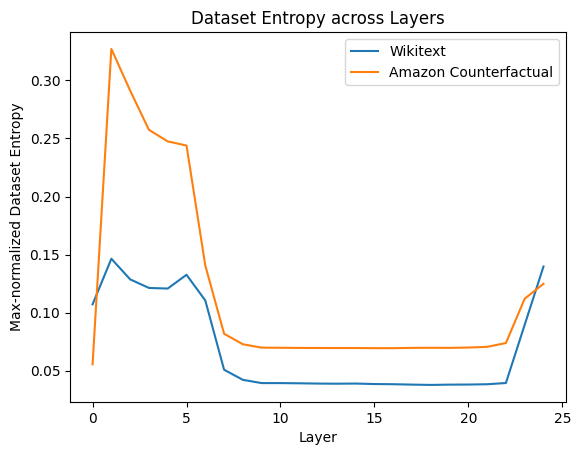

In [8]:
plt.plot(wikitext_dataset_entropy['maxEntropy'], label='Wikitext')
plt.plot(mteb_amazon_counterfactual_dataset_entropy['maxEntropy'], label='Amazon Counterfactual')
plt.xlabel('Layer')
plt.ylabel('Max-normalized Dataset Entropy')
plt.title('Dataset Entropy across Layers')
plt.legend()
plt.show()

# DiME

DiME is the first metric we show here which requires augmentations of the text. Lets make some

In [3]:
augmented_wikitext = get_augmentation_collated_dataloader(
    model.tokenizer,
    "wikitext", 
    split="train", 
    num_samples=1000, 
    batch_size=optimal_batch_size,
    num_workers=4,
    filter_text_columns=True,
    num_augmentations_per_sample=2
)

augmented_amazon_counterfactual = get_augmentation_collated_dataloader(
    model.tokenizer,
    "mteb/amazon_counterfactual", 
    split="train", 
    num_samples=1000, 
    batch_size=optimal_batch_size,
    num_workers=4,
    filter_text_columns=True,
    num_augmentations_per_sample=2
)

Using the latest cached version of the dataset since wikitext couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'wikitext-103-v1' at /home/AD/ofsk222/.cache/huggingface/datasets/wikitext/wikitext-103-v1/0.0.0/b08601e04326c79dfdd32d625aee71d232d685c3 (last modified on Mon Jan 27 15:51:28 2025).


Filter:   0%|          | 0/1000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/825 [00:00<?, ? examples/s]

Map:   0%|          | 0/472 [00:00<?, ? examples/s]

Map:   0%|          | 0/472 [00:00<?, ? examples/s]

...

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Using the latest cached version of the module from /home/AD/ofsk222/.cache/huggingface/modules/datasets_modules/datasets/mteb--amazon_counterfactual/3b6ae425288b4ec49ffa16445fa595593e9c00e210da62c9cf576ad2acfe4a8b (last modified on Tue Sep 17 01:09:23 2024) since it couldn't be found locally at mteb/amazon_counterfactual, or remotely on the Hugging Face Hub.
Repo card metadata block was not found. Setting CardData to empty.


Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [4]:
print('heelo')

heelo


In [5]:
# detokenize the augmented datasets to observe a sample
for batch in augmented_wikitext:
    for augmentation in batch:
        print(model.tokenizer.decode(augmentation['input_ids'][0]))
    break


['Regional algporta, s (Mh as EdVvburRh Airport, 0a9e experienced strong growth in CAT operations in recent ye ars. ^ hece operations are commercially and operationally incompatible wct & GA, and XlthiuFh there is no evidence of deliberate dicc3imiHariob, the effect has cJen to discourage or exclude it. GA air craft are be (n (s tb,2ct to xJgnifjcWnt in creases in cha rges, 5Zcljding the imposi wpon of handling fe es in s ome cases. Some aur(oets restrict or deny GA parking, and others limit or ref use certain GA activity. As a result, light GA aircraft are now ra%eky or never @ cen at la#he, b usy interja$ioba, WurporGs s uch as Heathrow, Stansted, Gatwick and Manchester.']<|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|end

In [10]:
evaluation_metric_specs = EvaluationMetricSpecifications(evaluation_metric="dime", alpha=1)

wikitext_dime = calculate_and_save_layerwise_metrics(
    model, 
    augmented_wikitext, 
    model_specs, 
    evaluation_metric_specs, 
    dataloader_kwargs={"num_samples": 1000, "dataset_name": "wikitext"},
    should_save_results=False
)

mteb_dime = calculate_and_save_layerwise_metrics(
    model, 
    augmented_amazon_counterfactual, 
    model_specs, 
    evaluation_metric_specs, 
    dataloader_kwargs={"num_samples": 1000, "dataset_name": "mteb/amazon_counterfactual"},
    should_save_results=False
)

0it [00:00, ?it/s]

7it [00:11,  1.66s/it]
16it [00:07,  2.27it/s]


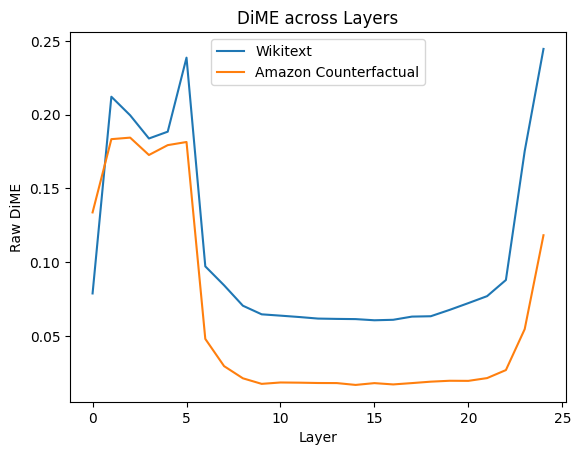

In [11]:
plt.plot(wikitext_dime['raw'], label='Wikitext')
plt.plot(mteb_dime['raw'], label='Amazon Counterfactual')
plt.xlabel('Layer')
plt.ylabel('Raw DiME')
plt.title('DiME across Layers')
plt.legend()
plt.show()

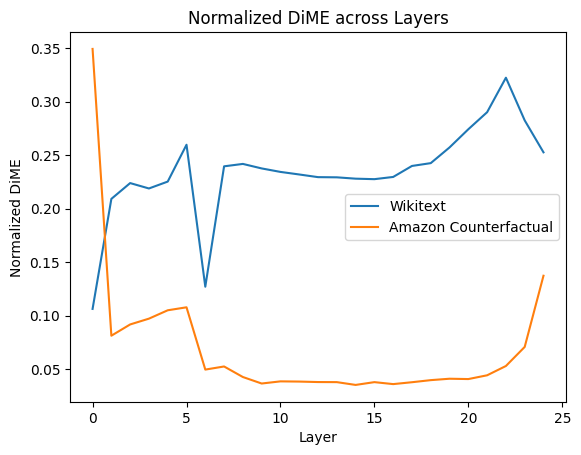

In [13]:
normalized_wikitext_dime = [wikitext_dime['raw'][i] / wikitext_dataset_entropy['raw'][i] for i in range(len(wikitext_dime['raw']))]
normalized_mteb_dime = [mteb_dime['raw'][i] / mteb_amazon_counterfactual_dataset_entropy['raw'][i] for i in range(len(mteb_dime['raw']))]

plt.plot(normalized_wikitext_dime, label='Wikitext')
plt.plot(normalized_mteb_dime, label='Amazon Counterfactual')
plt.xlabel('Layer')
plt.ylabel('Normalized DiME')
plt.title('Normalized DiME across Layers')
plt.legend()
plt.show()

## infoNCE

here we can use the same augmented datasets as in the DiME section

In [16]:
augmented_wikitext = get_augmentation_collated_dataloader(
    model.tokenizer,
    "wikitext", 
    split="train", 
    num_samples=1000, 
    batch_size=optimal_batch_size,
    num_workers=4,
    filter_text_columns=True,
    num_augmentations_per_sample=2
)

augmented_amazon_counterfactual = get_augmentation_collated_dataloader(
    model.tokenizer,
    "mteb/amazon_counterfactual", 
    split="train", 
    num_samples=1000, 
    batch_size=optimal_batch_size,
    num_workers=4,
    filter_text_columns=True,
    num_augmentations_per_sample=2
)

Using the latest cached version of the dataset since wikitext couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'wikitext-103-v1' at /home/AD/ofsk222/.cache/huggingface/datasets/wikitext/wikitext-103-v1/0.0.0/b08601e04326c79dfdd32d625aee71d232d685c3 (last modified on Mon Jan 27 15:51:28 2025).


Filter:   0%|          | 0/1000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/825 [00:00<?, ? examples/s]

Map:   0%|          | 0/472 [00:00<?, ? examples/s]

Map:   0%|          | 0/472 [00:00<?, ? examples/s]

...

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Using the latest cached version of the module from /home/AD/ofsk222/.cache/huggingface/modules/datasets_modules/datasets/mteb--amazon_counterfactual/3b6ae425288b4ec49ffa16445fa595593e9c00e210da62c9cf576ad2acfe4a8b (last modified on Tue Sep 17 01:09:23 2024) since it couldn't be found locally at mteb/amazon_counterfactual, or remotely on the Hugging Face Hub.
Repo card metadata block was not found. Setting CardData to empty.


Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [17]:
evaluation_metric_specs = EvaluationMetricSpecifications(evaluation_metric="infonce")

wikitext_infoNCE = calculate_and_save_layerwise_metrics(
    model, 
    augmented_wikitext, 
    model_specs, 
    evaluation_metric_specs, 
    dataloader_kwargs={"num_samples": 1000, "dataset_name": "wikitext"},
    should_save_results=False
)

mteb_infoNCE = calculate_and_save_layerwise_metrics(
    model, 
    augmented_amazon_counterfactual, 
    model_specs, 
    evaluation_metric_specs, 
    dataloader_kwargs={"num_samples": 1000, "dataset_name": "mteb/amazon_counterfactual"},
    should_save_results=False
)

0it [00:00, ?it/s]

8it [00:13,  1.65s/it]
16it [00:07,  2.28it/s]


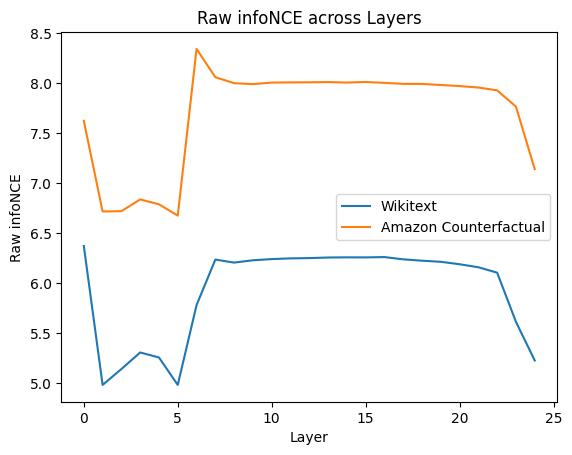

In [22]:
plt.plot(wikitext_infoNCE['raw'], label='Wikitext')
plt.plot(mteb_infoNCE['raw'], label='Amazon Counterfactual')
plt.xlabel('Layer')
plt.ylabel('Raw infoNCE')
plt.title('Raw infoNCE across Layers')
plt.legend()
plt.show()

# LiDAR

lidar requires more augmentations so lets use 16 here, as in the paper

In [24]:
augmented_wikitext = get_augmentation_collated_dataloader(
    model.tokenizer,
    "wikitext", 
    split="train", 
    num_samples=1000, 
    batch_size=optimal_batch_size,
    num_workers=4,
    filter_text_columns=True,
    num_augmentations_per_sample=16
)

Using the latest cached version of the dataset since wikitext couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'wikitext-103-v1' at /home/AD/ofsk222/.cache/huggingface/datasets/wikitext/wikitext-103-v1/0.0.0/b08601e04326c79dfdd32d625aee71d232d685c3 (last modified on Mon Jan 27 15:51:28 2025).


Filter:   0%|          | 0/1000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/825 [00:00<?, ? examples/s]

Map:   0%|          | 0/472 [00:00<?, ? examples/s]

Map:   0%|          | 0/472 [00:00<?, ? examples/s]

...

Using the latest cached version of the dataset since wikitext couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'wikitext-103-v1' at /home/AD/ofsk222/.cache/huggingface/datasets/wikitext/wikitext-103-v1/0.0.0/b08601e04326c79dfdd32d625aee71d232d685c3 (last modified on Mon Jan 27 15:51:28 2025).


Filter:   0%|          | 0/1000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/825 [00:00<?, ? examples/s]

Map:   0%|          | 0/472 [00:00<?, ? examples/s]

Map:   0%|          | 0/472 [00:00<?, ? examples/s]

In [ ]:
evaluation_metric_specs = EvaluationMetricSpecifications(evaluation_metric="lidar")

wikitext_lidar = calculate_and_save_layerwise_metrics(
    model, 
    augmented_wikitext, 
    model_specs, 
    evaluation_metric_specs, 
    dataloader_kwargs={"num_samples": 1000, "dataset_name": "wikitext"},
    should_save_results=False
)

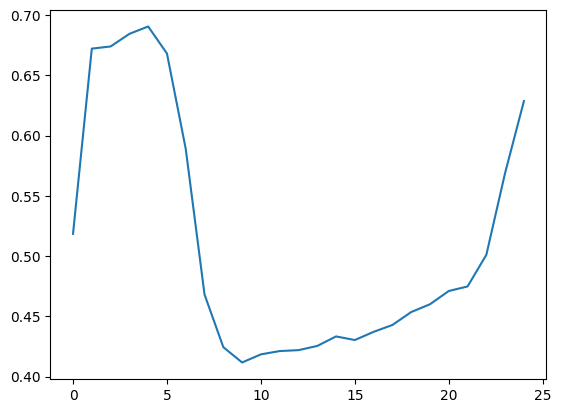

In [27]:
plt.plot(wikitext_lidar['maxEntropy'], label='Wikitext')

In [ ]:
raise SystemExit("things below are not in paper")

# Intrinsic Dimension

In [ ]:
sample_ids = []
hs = []
for batch in tqdm.tqdm(dataloader):
    batch = model.prepare_inputs(batch)
    outputs = model(**batch)

    sample_hidden_states = [mf.normalize(layer_states.squeeze().detach()) for layer_states in outputs.hidden_states]
    sample_hidden_states = torch.stack(sample_hidden_states) # L x NUM_TOKENS x D
    hs.append(sample_hidden_states)

# remove everything but last token
hs = [hs[i][:, -1, :] for i in range(len(hs))]

# stack batch
hs = torch.stack(hs)

In [ ]:
hs.shape

In [13]:
from dadapy.data import Data as ID_DATA

ids = []
for layer in hs:
    layer = layer.detach().float().squeeze().cpu().numpy()
    data = ID_DATA(layer)
    id, id_error, id_distance = data.compute_id_2NN()
    ids.append(id)

In [ ]:
# plot the intrinsic dimension
# get the average intrinsic dimension
plt.plot(ids)
plt.show()


In [ ]:
evaluation_metric_specs = EvaluationMetricSpecifications(evaluation_metric="intrinsic_dimension")
dataloader_kwargs = {"dataset_name": "wikitext"}

results = calculate_and_save_layerwise_metrics(
    model, 
    dataloader, 
    model_specs, 
    evaluation_metric_specs, 
    dataloader_kwargs
)

In [68]:
from utils.misc.results_saving import load_results
results = load_results(model_specs, evaluation_metric_specs, dataloader_kwargs)

In [ ]:
print(results)

In [ ]:
# plot the results
plt.plot(results['raw'])
plt.show()

# Fractal 1D

In [ ]:
# load input string from dissertation.txt
with open('/home/AD/ofsk222/Research/exploration/information_plane/dissertation.txt', 'r') as file:
    input_string = file.read()

# tokenize the input string
tokenized_string = model.tokenizer(input_string, truncation=True, max_length=2048, return_tensors='pt')
tokenized_string = {k: v.to(model.device) for k, v in tokenized_string.items()}

tokenized_string['input_ids'].shape

In [ ]:
#for i in range(len(tokenized_string['input_ids'][0])):
correct_next_token_bits = []
start_idx = 2
for N in tqdm.tqdm(range(start_idx, len(tokenized_string['input_ids'][0]))):
    with torch.no_grad():
        trunc_string = {
            'input_ids': tokenized_string['input_ids'][0][:N].unsqueeze(0),
            'attention_mask': tokenized_string['attention_mask'][0][:N].unsqueeze(0)
        }
        correct_token = tokenized_string['input_ids'][0][N]

        outputs = model(**trunc_string)
        hidden_states = outputs.hidden_states

        next_token_logits = outputs.logits[:, -1, :]
        next_token_probs = torch.log_softmax(next_token_logits, dim=-1)
        correct_token_prob = next_token_probs[0, correct_token]
        correct_token_bits = -correct_token_prob

        correct_next_token_bits.append(correct_token_bits.item())

plt.plot(correct_next_token_bits)
plt.show()


In [ ]:
bits_mean = np.mean(correct_next_token_bits)
bits_std = np.std(correct_next_token_bits)
bits_mean, bits_std


In [ ]:
increment_process = []
integral_process = []

mu = np.mean(correct_next_token_bits)
sigma = np.std(correct_next_token_bits)

increment_process = (correct_next_token_bits - mu) / sigma
integral_process = np.cumsum(increment_process)
increment_process.shape, integral_process.shape


In [ ]:
plt.plot(increment_process)
plt.show()

In [ ]:
plt.plot(integral_process)
plt.show()

In [ ]:
paragraphs = [242, 320, 409, 495, 755, 825, 944, 1135, 1264, 1518, 1697, 1957]

plt.plot(integral_process)
for paragraph in paragraphs:
    plt.axvline(paragraph, color='red', linestyle='--', alpha=0.3)

plt.xlabel("Token Index")
plt.ylabel("Cumulative Normalized Surprisal")
plt.title("Cumulative Normalized Surprisal of the Proposal Document")
plt.legend(["Cumulative Surprisal", "New Paragraph"], loc="upper right")

# put text in the top left which shows the self similarity exponent
plt.text(0.02, 0.95, f"    Self Sim. = 0.52", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top',)
plt.text(0.02, 0.90, f"         Hurst = 0.67", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top',)
plt.text(0.02, 0.85, f"        Joseph = 0.34", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top',)
plt.text(0.02, 0.80, f"Fractal Dim. = 1.47", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top',)

plt.savefig("2048_cumulative_normalized_surprisal.pdf")
plt.show()

In [ ]:
# plot the values from 500 to 750
plt.plot([0]*500 + list(integral_process[500:750]))

# make the x axis start at 500, end at 750
plt.xlim(500, 750)
plt.xlabel("Token Index")
plt.ylabel("Cumulative Normalized Surprisal")

plt.savefig("500_750_cumulative_normalized_surprisal.pdf")
plt.show()

In [117]:
import sklearn.linear_model

def power_law_fit(x, y):
  """Fit a power law to the data (x, y)."""
  ones_logx = np.stack([np.ones_like(x), np.log(x)], axis=1)
  logy = np.log(y)
  print(logy)
  clf = sklearn.linear_model.LinearRegression(
      fit_intercept=False).fit(ones_logx, logy)
  return clf.coef_[0], clf.coef_[1]  # coeff, exponent


def get_self_sim_exponent(X,
                          scales=[25, 50, 75, 100, 200, 250],
                          samples_per_doc=1000,
                          eps=5e-1):
  """Calculate the self-similarity exponent.

  Args:
    X: integral process, 1D or 2D array.
    scales: granuality levels. Choose this carefully.
      If it is too large, you will have very few measurements.
      If it is too small, your estimate of the power law relation will be
      unreliable.
    samples_per_doc: number of samples per document. Ideally, this should be
      small and the number of documents should be large.
    eps: used for calculating peak probability scores. Choose this carefully.
      If eps is too small, probability estimates will be unreliable.
      If eps is too large, it doesn't reflect peak probabiliy at the origin.

  Returns:
    S: self-similarity exponent.
    p0: peak probability estimates.
  """
  if X.ndim == 1:
    X = X.reshape((1, -1))
  elif X.ndim > 2:
    raise ValueError('X.ndim must be 1 or 2.')

  p0 = []
  for n in scales:
    all = []
    for i in (range(len(X))):
      for idx in range(samples_per_doc):
        print(idx)
        offset = np.random.randint(0, len(X[i]) - n)
        all.append(X[i][offset + n] - X[i][offset])
    all = np.array(all)
    p0.append(np.mean(np.abs(all) < eps))

  # estimate Holder exponent
  print(p0)
  return -power_law_fit(scales, p0)[1], p0
     

In [ ]:
np.random.seed(2024)
self_sim_exponent = get_self_sim_exponent(integral_process, eps=4e-1)


print(self_sim_exponent)

In [129]:
def get_hurst_exponent(x,
                       scales=[25, 50, 75, 100, 200, 250],
                       samples_per_doc=1000):
  """Calculate the Hurst exponent.

  Args:
    x: increment process, 1D or 2D array.
    scales: granuality levels. Choose this carefully.
      If it is too large, you will have very few measurements.
      If it is too small, your estimate of the power law relation will be
      unreliable.
    samples_per_doc: number of samples per document. Ideally, this should be
      small and the number of documents should be large.

  Returns:
    H: Hurst exponent.
    sr: rescaled range estimates.
  """
  if x.ndim == 1:
    x = x.reshape((1, -1))
  elif x.ndim > 2:
    raise ValueError('x.ndim must be 1 or 2.')

  # calculate the rescaled range
  sr = []
  for n in scales:
    som = 0
    count = 0
    for i in range(len(x)):  # to get a reliable etimate, many documents are needed
      for _ in range(samples_per_doc):
        offset = np.random.randint(0, len(x[i]) - n)
        y = x[i, offset: n + offset]
        y = y - np.mean(y)
        Y = np.cumsum(y)
        R = max(Y) - min(Y)
        S = np.std(y)
        som += R / S
        count += 1
    sr.append(som / count)

  # estimate Hurst exponent
  return power_law_fit(scales, sr)[1], sr

In [ ]:
np.random.seed(2024)
hurst_exponent = get_hurst_exponent(increment_process)
print(hurst_exponent)

In [150]:
def get_joseph_exponent(seq,
                        scales=[25, 50, 75, 100, 200, 250],
                        samples_per_doc=1000):
  """Calculate the Joseph exponent.

  Args:
    x: increment process, 1D or 2D array.
    scales: granuality levels. Choose this carefully.
      If it is too large, you will have very few measurements.
      If it is too small, your estimate of the power law relation will be
      unreliable.
    samples_per_doc: number of samples per document. Ideally, this should be
      small and the number of documents should be large.

  Returns:
    J: Joseph exponent.
    sigmas: standard deviations estimate.
  """
  if seq.ndim == 1:
    seq = seq.reshape((1, -1))
  elif seq.ndim > 2:
    raise ValueError('x.ndim must be 1 or 2.')

  sigmas = []
  v = []
  for n in scales:
    for i in range(len(seq)):
      for _ in range(samples_per_doc):
        offset = np.random.randint(0, len(seq[i]) - n)
        v.extend([seq[i][offset + n] - seq[i][offset]])
    sigmas.append(np.std(v))

  # estimate Joseph exponent
  return power_law_fit(scales, sigmas)[1], sigmas

In [ ]:
get_joseph_exponent(integral_process)

In [ ]:
# compute the fractal dimension
fractal_dimension = 1 - self_sim_exponent[0]
print(fractal_dimension)

In [161]:
def fractal_dimension(data, 
                      epsilons = [25, 50, 75, 100, 200, 250]):
    """
    Computes the fractal dimension of a 1D list using the box-counting method.

    Parameters:
        data (list or np.array): The input 1D list or array.
        epsilons (list or np.array): List of box sizes to evaluate.

    Returns:
        fractal_dim (float): The computed fractal dimension.
    """
    data = np.array(data)
    box_counts = []

    for epsilon in epsilons:
        # Find the number of boxes that contain at least one point
        bins = np.arange(data.min(), data.max() + epsilon, epsilon)
        digitized = np.digitize(data, bins)
        box_count = len(np.unique(digitized))
        box_counts.append(box_count)

    # Convert to log-log space
    log_epsilons = np.log(1 / np.array(epsilons))
    log_box_counts = np.log(box_counts)

    # Fit a line to find the slope, which is the fractal dimension
    coeffs = np.polyfit(log_epsilons, log_box_counts, 1)
    fractal_dim = coeffs[0]

    # Plot for visualization
    plt.figure(figsize=(8, 6))
    plt.plot(log_epsilons, log_box_counts, 'o-', label="Data")
    plt.plot(log_epsilons, np.polyval(coeffs, log_epsilons), 'r--', label="Fit")
    plt.xlabel("log(1/epsilon)")
    plt.ylabel("log(box count)")
    plt.legend()
    plt.title("Fractal Dimension Estimation")
    plt.show()

    return fractal_dim

In [ ]:
fractal_dim = 2 - self_sim_exponent[0]
print(fractal_dim)

## Try different Sizes of model

In [ ]:
from utils.model_definitions.text_automodel_wrapper import TextLayerwiseAutoModelWrapper, TextModelSpecifications

sizes = ["14m", "70m", "160m", "410m", "1b", "1.4b"]
#sizes = ["14m", "70m"]
size_to_correct_next_token_bits = {}

for size in sizes:
    model_specs = TextModelSpecifications(
        model_family="Pythia",
        model_size=size,
        revision="main"
        )
    model = TextLayerwiseAutoModelWrapper(model_specs, device_map="auto")

    # load input string from dissertation.txt
    with open('/home/AD/ofsk222/Research/exploration/information_plane/dissertation.txt', 'r') as file:
        input_string = file.read()

    # tokenize the input string
    tokenized_string = model.tokenizer(input_string, truncation=True, max_length=2048, return_tensors='pt')
    tokenized_string = {k: v.to(model.device) for k, v in tokenized_string.items()}

    tokenized_string['input_ids'].shape

    correct_next_token_bits = []
    start_idx = 2
    for N in tqdm.tqdm(range(start_idx, len(tokenized_string['input_ids'][0]))):
        trunc_string = {
            'input_ids': tokenized_string['input_ids'][0][:N].unsqueeze(0),
            'attention_mask': tokenized_string['attention_mask'][0][:N].unsqueeze(0)
        }
        correct_token = tokenized_string['input_ids'][0][N]

        outputs = model(**trunc_string)
        hidden_states = outputs.hidden_states

        next_token_logits = outputs.logits[:, -1, :]
        next_token_probs = torch.log_softmax(next_token_logits, dim=-1)
        correct_token_prob = next_token_probs[0, correct_token]
        correct_token_bits = -correct_token_prob

        correct_next_token_bits.append(correct_token_bits.item())

    size_to_correct_next_token_bits[size] = correct_next_token_bits
    del model

In [6]:
size_to_increment_process = {}
size_to_integral_process = {}

for size in sizes:
    correct_next_token_bits = size_to_correct_next_token_bits[size]

    mu = np.mean(correct_next_token_bits)
    sigma = np.std(correct_next_token_bits)

    increment_process = (correct_next_token_bits - mu) / sigma
    integral_process = np.cumsum(increment_process)

    size_to_increment_process[size] = increment_process
    size_to_integral_process[size] = integral_process

In [ ]:
# plot the results
# Create color map from light to dark green based on index
for i, size in enumerate(sizes):
    # Normalize index to [0,1] range for color intensity 
    color_intensity = i / (len(sizes) - 1)
    color = (0, 0.2 + 0.8 * color_intensity, 0)  # Varying shades of green
    if size in ["14m", "160m", "1.4b"]:
        plt.plot(size_to_integral_process[size], color=color, label=f'{size}')
plt.legend()

plt.title("Integral Process of the Proposal Document for Different Pythia Sizes")
plt.xlabel("Token Index")
plt.ylabel("Cumulative Normalized Surprisal")
plt.show()
